# Figure 4. OpenXAI-inspired Explanation Reliability Analysis

This notebook generates a 170 mm-wide publication-style Figure 4 for ICU mortality explanation reliability.

**Models**
- Logistic Regression
- Linear SVM
- XGBoost

**Panels**
- **a)** Cross-fold explanation stability
- **b)** False explanation rate after random noise feature injection
- **c)** Agreement across explanation methods
- **d)** Clinical-domain composition / false-inference audit

Run this notebook from the `OpenXAI/code/` folder, with data stored in `OpenXAI/data/`.


In [7]:
# ============================================================
# Figure 4. OpenXAI-inspired explanation reliability analysis
# Models: Logistic Regression, Linear SVM, XGBoost
#
# Recommended folder structure:
#   OpenXAI/
#   ├── data/
#   │   ├── X_train.csv
#   │   ├── X_test.csv
#   │   ├── y_train.csv
#   │   ├── y_test.csv
#   │   └── cohort_distribution_dataset.csv
#   └── code/
#       └── make_figure4_explanation_reliability.ipynb
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "xgboost is required. Install with: pip install xgboost"
    ) from e

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("WARNING: shap is not installed. XGBoost explanation will fall back to feature_importances_.")


In [8]:
# ============================================================
# 0. Global settings
# ============================================================

RANDOM_SEED = 42
TOP_K = 20
CV_FOLDS = 5

# Noise-injection setting for false explanation test
N_GAUSSIAN_NOISE = 20
N_PERMUTED_NOISE = 20
N_NOISE_REPEATS = 3

# Explanation sampling setting to reduce runtime
EXPLAIN_N = 1500
PERMUTATION_N = 1500
PERMUTATION_REPEATS = 5

# PNAS-style publication sizing
FIG_WIDTH_MM = 170
FIG_HEIGHT_MM = 145

# If notebook is inside OpenXAI/code, this works.
DATA_DIR = Path("../data")
OUT_DIR = Path("../figures/Figure4")
RESULT_DIR = Path("../results/Figure4")

OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

FIG_PNG = OUT_DIR / "Figure4_explanation_reliability_170mm.png"
FIG_PDF = OUT_DIR / "Figure4_explanation_reliability_170mm.pdf"

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())
print("RESULT_DIR:", RESULT_DIR.resolve())


DATA_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\data
OUT_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Figure4
RESULT_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4


In [9]:
# ============================================================
# 1. Load data
# ============================================================

def find_file(data_dir, expected_name):
    """
    Finds an expected CSV file.
    First tries exact name, then falls back to a prefix match such as X_train*.csv.
    This helps if the downloaded file is named like X_train(10).csv.
    """
    exact = data_dir / expected_name
    if exact.exists():
        return exact

    stem = expected_name.replace(".csv", "")
    matches = sorted(data_dir.glob(f"{stem}*.csv"))
    if matches:
        print(f"Using {matches[0].name} for expected file {expected_name}")
        return matches[0]

    raise FileNotFoundError(f"Cannot find {expected_name} or {stem}*.csv in {data_dir.resolve()}")


def clean_columns(df):
    df = df.copy()
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    return df


def read_y(path):
    df = clean_columns(pd.read_csv(path))

    preferred_cols = [
        "in_hospital_death",
        "In-hospital_death",
        "InHospitalDeath",
        "mortality",
        "death",
        "label",
        "target",
        "y",
    ]

    for c in preferred_cols:
        if c in df.columns:
            return df[c].astype(int)

    if df.shape[1] == 1:
        return df.iloc[:, 0].astype(int)

    raise ValueError(
        f"Could not identify label column in {path}. "
        f"Columns found: {list(df.columns)}"
    )


def drop_leakage_columns(X):
    X = X.copy()

    leakage_names = {
        "recordid",
        "record_id",
        "in_hospital_death",
        "inhospitaldeath",
        "survival",
        "length_of_stay",
        "lengthofstay",
        "saps-i",
        "saps_i",
        "sofa",
    }

    drop_cols = []
    for c in X.columns:
        c_norm = str(c).lower().replace(" ", "_")
        if c_norm in leakage_names:
            drop_cols.append(c)

    if drop_cols:
        print("Dropping possible leakage/id columns:", drop_cols)
        X = X.drop(columns=drop_cols)

    return X


X_train_path = find_file(DATA_DIR, "X_train.csv")
X_test_path = find_file(DATA_DIR, "X_test.csv")
y_train_path = find_file(DATA_DIR, "y_train.csv")
y_test_path = find_file(DATA_DIR, "y_test.csv")

X_train = clean_columns(pd.read_csv(X_train_path))
X_test = clean_columns(pd.read_csv(X_test_path))
y_train = read_y(y_train_path)
y_test = read_y(y_test_path)

X_train = drop_leakage_columns(X_train)
X_test = drop_leakage_columns(X_test)

common_cols = [c for c in X_train.columns if c in X_test.columns]
X_train = X_train[common_cols].copy()
X_test = X_test[common_cols].copy()

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("y_train mortality rate:", float(np.mean(y_train)))
print("y_test mortality rate :", float(np.mean(y_test)))

display(X_train.head())


X_train: (8000, 243)
X_test : (4000, 243)
y_train: (8000,)
y_test : (4000,)
y_train mortality rate: 0.14025
y_test mortality rate : 0.14625


,BUN_count,BUN_first,BUN_last,BUN_max,BUN_mean,BUN_median,BUN_min,BUN_missing,BUN_std,Creatinine_count,...,pH_mean,pH_median,pH_min,pH_missing,pH_std,static_Age,static_Gender,static_Height,static_ICUType,static_Weight
0,2.0,13.0,8.0,13.0,10.500000,10.5,8.0,0.0,3.535534,2.0,...,7.45267,7.420371,7.341433,1.0,0.171855,54.0,0.0,169.724569,4.0,81.51839
1,3.0,16.0,21.0,21.0,18.333333,18.0,16.0,0.0,2.516611,3.0,...,7.39500,7.400000,7.340000,0.0,0.037796,76.0,1.0,175.300000,2.0,76.00000
2,3.0,8.0,3.0,8.0,4.666667,3.0,3.0,0.0,2.886751,3.0,...,7.49500,7.500000,7.470000,0.0,0.017321,44.0,0.0,169.724569,3.0,56.70000
3,3.0,23.0,10.0,23.0,17.666667,20.0,10.0,0.0,6.806859,3.0,...,7.45267,7.420371,7.341433,1.0,0.171855,68.0,1.0,180.300000,3.0,84.60000
4,2.0,45.0,25.0,45.0,35.000000,35.0,25.0,0.0,14.142136,2.0,...,7.45267,7.420371,7.341433,1.0,0.171855,88.0,0.0,169.724569,3.0,81.51839


In [10]:
# ============================================================
# 2. Helper functions
# ============================================================

def top_k_features(importance, k=TOP_K):
    return list(importance.sort_values(ascending=False).head(k).index)


def jaccard(a, b):
    a = set(a)
    b = set(b)
    if len(a | b) == 0:
        return np.nan
    return len(a & b) / len(a | b)


def pairwise_jaccard_mean(top_sets):
    values = []
    for i in range(len(top_sets)):
        for j in range(i + 1, len(top_sets)):
            values.append(jaccard(top_sets[i], top_sets[j]))
    return float(np.nanmean(values)), float(np.nanstd(values)), values


def stratified_sample_indices(y, max_n, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    y_arr = np.asarray(y)

    if len(y_arr) <= max_n:
        return np.arange(len(y_arr))

    idx_all = []
    classes, counts = np.unique(y_arr, return_counts=True)

    for cls, count in zip(classes, counts):
        cls_idx = np.where(y_arr == cls)[0]
        n_cls = int(round(max_n * count / len(y_arr)))
        n_cls = max(1, min(n_cls, len(cls_idx)))
        idx_all.extend(rng.choice(cls_idx, size=n_cls, replace=False).tolist())

    idx_all = np.array(idx_all)

    if len(idx_all) > max_n:
        idx_all = rng.choice(idx_all, size=max_n, replace=False)

    rng.shuffle(idx_all)
    return idx_all


def get_scale_pos_weight(y):
    y = np.asarray(y)
    pos = np.sum(y == 1)
    neg = np.sum(y == 0)
    if pos == 0:
        return 1.0
    return neg / pos


def make_xgb(seed=RANDOM_SEED, scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=seed,
        n_jobs=-1,
    )


In [11]:
# ============================================================
# 3. Model-specific explanation functions
# ============================================================

def logistic_importance(X_tr, y_tr):
    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    pipe.fit(X_tr, y_tr)
    coefs = np.abs(pipe.named_steps["model"].coef_[0])
    return pd.Series(coefs, index=X_tr.columns).sort_values(ascending=False)


def svm_importance(X_tr, y_tr):
    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LinearSVC(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=20000,
                    dual=False,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    pipe.fit(X_tr, y_tr)
    coefs = np.abs(pipe.named_steps["model"].coef_[0])
    return pd.Series(coefs, index=X_tr.columns).sort_values(ascending=False)


def xgb_shap_importance(X_tr, y_tr, X_eval, seed=RANDOM_SEED):
    imputer = SimpleImputer(strategy="median")
    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )
    X_eval_imp = pd.DataFrame(
        imputer.transform(X_eval),
        columns=X_eval.columns,
        index=X_eval.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    idx = stratified_sample_indices(
        np.zeros(len(X_eval_imp)),
        max_n=min(EXPLAIN_N, len(X_eval_imp)),
        seed=seed,
    )
    X_exp = X_eval_imp.iloc[idx]

    if HAS_SHAP:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_exp)

        if isinstance(shap_values, list):
            shap_values = shap_values[-1]

        shap_values = np.asarray(shap_values)

        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, -1]

        vals = np.mean(np.abs(shap_values), axis=0)
        return pd.Series(vals, index=X_tr.columns).sort_values(ascending=False)

    vals = model.feature_importances_
    return pd.Series(vals, index=X_tr.columns).sort_values(ascending=False)


def xgb_permutation_importance(X_tr, y_tr, X_eval, y_eval, seed=RANDOM_SEED):
    imputer = SimpleImputer(strategy="median")
    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )
    X_eval_imp = pd.DataFrame(
        imputer.transform(X_eval),
        columns=X_eval.columns,
        index=X_eval.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    idx = stratified_sample_indices(
        y_eval,
        max_n=min(PERMUTATION_N, len(X_eval_imp)),
        seed=seed,
    )

    X_perm = X_eval_imp.iloc[idx]
    y_perm = np.asarray(y_eval)[idx]

    result = permutation_importance(
        model,
        X_perm,
        y_perm,
        scoring="roc_auc",
        n_repeats=PERMUTATION_REPEATS,
        random_state=seed,
        n_jobs=-1,
    )

    vals = np.maximum(result.importances_mean, 0)
    return pd.Series(vals, index=X_tr.columns).sort_values(ascending=False)


def compute_importance(model_name, X_tr, y_tr, X_eval=None, y_eval=None, seed=RANDOM_SEED):
    if model_name == "Logistic Regression":
        return logistic_importance(X_tr, y_tr)

    if model_name == "Linear SVM":
        return svm_importance(X_tr, y_tr)

    if model_name == "XGBoost":
        if X_eval is None:
            X_eval = X_tr
        return xgb_shap_importance(X_tr, y_tr, X_eval, seed=seed)

    if model_name == "XGBoost Permutation":
        if X_eval is None or y_eval is None:
            raise ValueError("XGBoost Permutation requires X_eval and y_eval.")
        return xgb_permutation_importance(X_tr, y_tr, X_eval, y_eval, seed=seed)

    raise ValueError(f"Unknown model_name: {model_name}")


In [12]:
# ============================================================
# 4. Panel A: explanation stability across CV folds
# Fixed version: avoid SHAP crash for XGBoost CV stability
# ============================================================

models_main = ["Logistic Regression", "Linear SVM", "XGBoost"]

def xgb_builtin_gain_importance(X_tr, y_tr, seed=RANDOM_SEED):
    """
    Safe fallback for XGBoost feature importance.
    This avoids shap.TreeExplainer errors caused by some SHAP/XGBoost version mismatches.
    """
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    booster = model.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance = pd.Series(0.0, index=X_tr.columns)

    for key, value in score_dict.items():
        # XGBoost sometimes returns feature names directly,
        # but sometimes returns f0, f1, f2...
        if key in importance.index:
            importance.loc[key] = value
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            if idx < len(X_tr.columns):
                importance.iloc[idx] = value

    return importance.sort_values(ascending=False)


def safe_compute_cv_importance(model_name, X_tr, y_tr, X_eval=None, seed=RANDOM_SEED):
    """
    For LR and SVM, use the original compute_importance().
    For XGBoost, use built-in gain importance for CV stability to avoid SHAP version errors.
    """
    if model_name == "XGBoost":
        return xgb_builtin_gain_importance(X_tr, y_tr, seed=seed)

    return compute_importance(
        model_name=model_name,
        X_tr=X_tr,
        y_tr=y_tr,
        X_eval=X_eval,
        seed=seed,
    )


stability_rows = []
cv_topsets = {}

skf = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED,
)

for model_name in models_main:
    print(f"\nComputing CV stability for {model_name}...")
    fold_sets = []

    for fold_id, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        importance = safe_compute_cv_importance(
            model_name=model_name,
            X_tr=X_tr,
            y_tr=y_tr,
            X_eval=X_val,
            seed=RANDOM_SEED + fold_id,
        )

        fold_sets.append(top_k_features(importance, TOP_K))

    mean_j, std_j, all_j = pairwise_jaccard_mean(fold_sets)

    stability_rows.append(
        {
            "model": model_name,
            "stability_mean": mean_j,
            "stability_std": std_j,
            "n_pairwise_fold_comparisons": len(all_j),
        }
    )

    cv_topsets[model_name] = fold_sets

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(RESULT_DIR / "figure4_panelA_stability.csv", index=False)
display(stability_df)


Computing CV stability for Logistic Regression...

Computing CV stability for Linear SVM...

Computing CV stability for XGBoost...


,model,stability_mean,stability_std,n_pairwise_fold_comparisons
0,Logistic Regression,0.427602,0.076525,10
1,Linear SVM,0.427159,0.071459,10
2,XGBoost,0.416535,0.065411,10


In [14]:
# ============================================================
# 5. Panel B + D: false explanation rate and domain composition
# Fixed version: avoid SHAP crash for XGBoost noise test
# ============================================================

def add_noise_features(X_tr, X_eval, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    X_tr_n = X_tr.copy()
    X_eval_n = X_eval.copy()

    numeric_cols = list(X_tr.columns)

    # Gaussian noise features
    train_noise_dict = {}
    eval_noise_dict = {}

    for i in range(1, N_GAUSSIAN_NOISE + 1):
        col = f"noise_gaussian_{i:02d}"
        train_noise_dict[col] = rng.normal(0, 1, size=len(X_tr_n))
        eval_noise_dict[col] = rng.normal(0, 1, size=len(X_eval_n))

    # Permuted real-feature noise
    chosen_cols = rng.choice(
        numeric_cols,
        size=N_PERMUTED_NOISE,
        replace=True,
    )

    for i, original_col in enumerate(chosen_cols, start=1):
        col = f"noise_permuted_{i:02d}_from_{original_col}"

        train_values = np.asarray(X_tr[original_col])
        eval_values = np.asarray(X_eval[original_col])

        train_noise_dict[col] = rng.permutation(train_values)
        eval_noise_dict[col] = rng.permutation(eval_values)

    X_tr_noise = pd.DataFrame(train_noise_dict, index=X_tr.index)
    X_eval_noise = pd.DataFrame(eval_noise_dict, index=X_eval.index)

    X_tr_n = pd.concat([X_tr_n, X_tr_noise], axis=1)
    X_eval_n = pd.concat([X_eval_n, X_eval_noise], axis=1)

    return X_tr_n, X_eval_n


def is_noise_feature(feature_name):
    return str(feature_name).lower().startswith("noise_")


def classify_domain(feature_name):
    f = str(feature_name).lower()

    if f.startswith("noise_"):
        return "Noise"

    if ("_count" in f) or ("missing" in f) or ("measured" in f) or ("observed" in f):
        return "Measurement process"

    if any(k in f for k in ["static_age", "age", "gender", "sex", "icutype", "height", "weight"]):
        return "Static / demographic"

    if any(k in f for k in ["bun", "creatinine", "urine"]):
        return "Renal"

    if any(k in f for k in ["hr", "heart", "sysabp", "diasabp", "map", "nimeanabp", "nisysabp", "nidiasabp", "troponin"]):
        return "Cardiovascular"

    if any(k in f for k in ["resp", "pao2", "paco2", "fio2", "sao2", "mechvent"]):
        return "Respiratory"

    if any(k in f for k in ["glucose", "lactate", "ph", "hco3", "baseexcess", "base_excess", "sodium", "potassium", "calcium", "magnesium", "temp"]):
        return "Metabolic / acid-base"

    if any(k in f for k in ["wbc", "platelet", "platelets", "hct", "hgb", "hemoglobin"]):
        return "Hematologic"

    if any(k in f for k in ["gcs"]):
        return "Neurological"

    return "Other clinical"


def xgb_builtin_gain_importance_for_noise(X_tr, y_tr, seed=RANDOM_SEED):
    """
    Safe XGBoost importance for Panel B/D.
    Uses built-in gain importance instead of SHAP to avoid SHAP-XGBoost base_score error.
    """
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    booster = model.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance = pd.Series(0.0, index=X_tr.columns)

    for key, value in score_dict.items():
        if key in importance.index:
            importance.loc[key] = value
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            if idx < len(X_tr.columns):
                importance.iloc[idx] = value

    return importance.sort_values(ascending=False)


def safe_compute_noise_importance(model_name, X_tr, y_tr, X_eval=None, seed=RANDOM_SEED):
    """
    LR and Linear SVM use the original compute_importance().
    XGBoost uses built-in gain importance to avoid SHAP error during noise-injection analysis.
    """
    if model_name == "XGBoost":
        return xgb_builtin_gain_importance_for_noise(
            X_tr=X_tr,
            y_tr=y_tr,
            seed=seed,
        )

    return compute_importance(
        model_name=model_name,
        X_tr=X_tr,
        y_tr=y_tr,
        X_eval=X_eval,
        seed=seed,
    )


fer_rows = []
domain_rows = []
noise_top_features_records = []

for repeat in range(N_NOISE_REPEATS):
    seed = RANDOM_SEED + 1000 + repeat

    X_train_noise, X_test_noise = add_noise_features(
        X_train,
        X_test,
        seed=seed,
    )

    for model_name in models_main:
        print(f"\nComputing false explanation rate for {model_name}, repeat {repeat + 1}...")

        importance = safe_compute_noise_importance(
            model_name=model_name,
            X_tr=X_train_noise,
            y_tr=y_train,
            X_eval=X_test_noise,
            seed=seed,
        )

        top_features = top_k_features(importance, TOP_K)

        n_noise = sum(is_noise_feature(f) for f in top_features)
        fer = n_noise / TOP_K

        fer_rows.append(
            {
                "repeat": repeat + 1,
                "model": model_name,
                "false_explanation_rate": fer,
                "n_noise_in_top_k": n_noise,
                "top_k": TOP_K,
            }
        )

        for rank, feat in enumerate(top_features, start=1):
            noise_top_features_records.append(
                {
                    "repeat": repeat + 1,
                    "model": model_name,
                    "rank": rank,
                    "feature": feat,
                    "is_noise": is_noise_feature(feat),
                    "domain": classify_domain(feat),
                    "importance": float(importance.loc[feat]),
                }
            )

        domain_counts = pd.Series([classify_domain(f) for f in top_features]).value_counts()

        for domain, count in domain_counts.items():
            domain_rows.append(
                {
                    "repeat": repeat + 1,
                    "model": model_name,
                    "domain": domain,
                    "proportion": count / TOP_K,
                    "count": count,
                }
            )


fer_df = pd.DataFrame(fer_rows)

fer_summary = (
    fer_df.groupby("model", as_index=False)
    .agg(
        fer_mean=("false_explanation_rate", "mean"),
        fer_std=("false_explanation_rate", "std"),
        mean_noise_count=("n_noise_in_top_k", "mean"),
    )
)

domain_df = pd.DataFrame(domain_rows)

domain_summary = (
    domain_df.groupby(["model", "domain"], as_index=False)
    .agg(proportion=("proportion", "mean"))
)

noise_top_features_df = pd.DataFrame(noise_top_features_records)

fer_df.to_csv(RESULT_DIR / "figure4_panelB_false_explanation_rate_repeats.csv", index=False)
fer_summary.to_csv(RESULT_DIR / "figure4_panelB_false_explanation_rate_summary.csv", index=False)
domain_summary.to_csv(RESULT_DIR / "figure4_panelD_domain_composition.csv", index=False)
noise_top_features_df.to_csv(RESULT_DIR / "figure4_noise_injection_top_features.csv", index=False)

display(fer_summary)
display(domain_summary.head(20))


Computing false explanation rate for Logistic Regression, repeat 1...

Computing false explanation rate for Linear SVM, repeat 1...

Computing false explanation rate for XGBoost, repeat 1...

Computing false explanation rate for Logistic Regression, repeat 2...

Computing false explanation rate for Linear SVM, repeat 2...

Computing false explanation rate for XGBoost, repeat 2...

Computing false explanation rate for Logistic Regression, repeat 3...

Computing false explanation rate for Linear SVM, repeat 3...

Computing false explanation rate for XGBoost, repeat 3...


,model,fer_mean,fer_std,mean_noise_count
0,Linear SVM,0.0,0.0,0.0
1,Logistic Regression,0.0,0.0,0.0
2,XGBoost,0.0,0.0,0.0


,model,domain,proportion
0,Linear SVM,Cardiovascular,0.050000
1,Linear SVM,Hematologic,0.150000
2,Linear SVM,Measurement process,0.350000
3,Linear SVM,Metabolic / acid-base,0.216667
4,Linear SVM,Renal,0.250000
5,Logistic Regression,Cardiovascular,0.166667
6,Logistic Regression,Hematologic,0.233333
7,Logistic Regression,Measurement process,0.150000
8,Logistic Regression,Metabolic / acid-base,0.100000
9,Logistic Regression,Neurological,0.083333


In [16]:
# ============================================================
# 6. Panel C: agreement across explanation methods
# Fixed version: use XGB gain instead of XGB SHAP to avoid SHAP-XGBoost error
# ============================================================

print("\nComputing method agreement...")

def xgb_builtin_gain_importance_for_agreement(X_tr, y_tr, seed=RANDOM_SEED):
    """
    Safe XGBoost importance for Panel C.
    Uses built-in gain importance instead of SHAP to avoid SHAP-XGBoost base_score error.
    """
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    booster = model.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance = pd.Series(0.0, index=X_tr.columns)

    for key, value in score_dict.items():
        if key in importance.index:
            importance.loc[key] = value
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            if idx < len(X_tr.columns):
                importance.iloc[idx] = value

    return importance.sort_values(ascending=False)


method_importances = {
    "LR coef.": compute_importance(
        "Logistic Regression",
        X_train,
        y_train,
        X_eval=X_test,
        seed=RANDOM_SEED,
    ),
    "SVM coef.": compute_importance(
        "Linear SVM",
        X_train,
        y_train,
        X_eval=X_test,
        seed=RANDOM_SEED,
    ),
    "XGB gain": xgb_builtin_gain_importance_for_agreement(
        X_train,
        y_train,
        seed=RANDOM_SEED,
    ),
    "XGB perm.": compute_importance(
        "XGBoost Permutation",
        X_train,
        y_train,
        X_eval=X_test,
        y_eval=y_test,
        seed=RANDOM_SEED,
    ),
}

method_topsets = {
    method: top_k_features(importance, TOP_K)
    for method, importance in method_importances.items()
}

methods = list(method_topsets.keys())

agreement_mat = pd.DataFrame(
    np.eye(len(methods)),
    index=methods,
    columns=methods,
)

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        agreement_mat.loc[m1, m2] = jaccard(method_topsets[m1], method_topsets[m2])

agreement_mat.to_csv(
    RESULT_DIR / "figure4_panelC_method_agreement_jaccard.csv"
)

top_features_export = []

for method, features in method_topsets.items():
    for rank, feat in enumerate(features, start=1):
        top_features_export.append(
            {
                "method": method,
                "rank": rank,
                "feature": feat,
                "domain": classify_domain(feat),
            }
        )

pd.DataFrame(top_features_export).to_csv(
    RESULT_DIR / "figure4_panelC_top_features_by_method.csv",
    index=False,
)

display(agreement_mat)
display(pd.DataFrame(top_features_export).head(30))


Computing method agreement...


,LR coef.,SVM coef.,XGB gain,XGB perm.
LR coef.,1.000000,0.428571,0.081081,0.052632
SVM coef.,0.428571,1.000000,0.081081,0.025641
XGB gain,0.081081,0.081081,1.000000,0.176471
XGB perm.,0.052632,0.025641,0.176471,1.000000


,method,rank,feature,domain
0,LR coef.,1,WBC_mean,Hematologic
1,LR coef.,2,pH_median,Metabolic / acid-base
2,LR coef.,3,Platelets_min,Hematologic
3,LR coef.,4,WBC_max,Hematologic
4,LR coef.,5,PaO2_count,Measurement process
5,LR coef.,6,NIMAP_missing,Measurement process
6,LR coef.,7,Creatinine_max,Renal
7,LR coef.,8,Urine_mean,Renal
8,LR coef.,9,GCS_mean,Neurological
9,LR coef.,10,pH_last,Metabolic / acid-base



Saved:
..\figures\Figure4\Figure4_explanation_reliability_170mm.png
..\figures\Figure4\Figure4_explanation_reliability_170mm.pdf

Saved result tables to:
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4


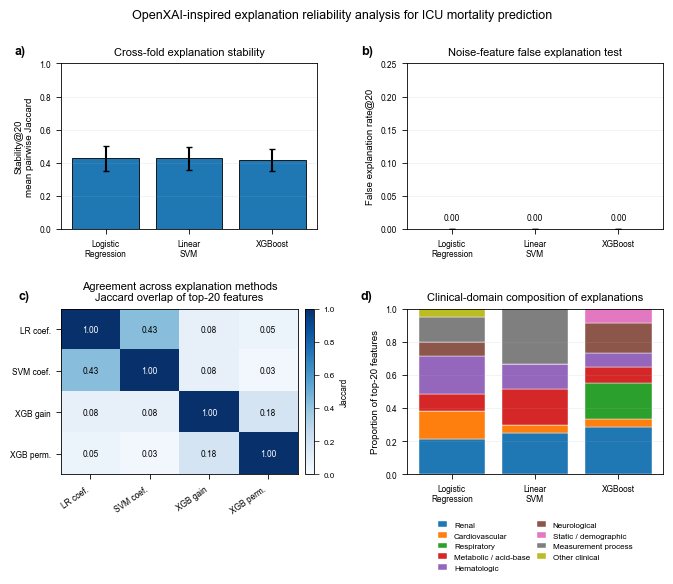

In [17]:
# ============================================================
# 7. Plot Figure 4
# ============================================================

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 5.8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
    }
)

fig_w = FIG_WIDTH_MM / 25.4
fig_h = FIG_HEIGHT_MM / 25.4

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.35,
    hspace=0.48,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])


def panel_label(ax, label):
    ax.text(
        -0.18,
        1.11,
        label,
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
    )


# ----------------------------
# Panel A
# ----------------------------
plot_models = ["Logistic Regression", "Linear SVM", "XGBoost"]
x = np.arange(len(plot_models))

stab_vals = [
    float(stability_df.loc[stability_df["model"] == m, "stability_mean"].iloc[0])
    for m in plot_models
]
stab_err = [
    float(stability_df.loc[stability_df["model"] == m, "stability_std"].iloc[0])
    for m in plot_models
]

axA.bar(x, stab_vals, yerr=stab_err, capsize=2.5, linewidth=0.6, edgecolor="black")
axA.set_xticks(x)
axA.set_xticklabels(["Logistic\nRegression", "Linear\nSVM", "XGBoost"])
axA.set_ylim(0, 1)
axA.set_ylabel(f"Stability@{TOP_K}\nmean pairwise Jaccard")
axA.set_title("Cross-fold explanation stability")
axA.grid(axis="y", alpha=0.25, linewidth=0.4)
panel_label(axA, "a)")


# ----------------------------
# Panel B
# ----------------------------
fer_vals = [
    float(fer_summary.loc[fer_summary["model"] == m, "fer_mean"].iloc[0])
    for m in plot_models
]
fer_err = [
    float(fer_summary.loc[fer_summary["model"] == m, "fer_std"].fillna(0).iloc[0])
    for m in plot_models
]

axB.bar(x, fer_vals, yerr=fer_err, capsize=2.5, linewidth=0.6, edgecolor="black")
axB.set_xticks(x)
axB.set_xticklabels(["Logistic\nRegression", "Linear\nSVM", "XGBoost"])
axB.set_ylim(0, max(0.25, min(1.0, max(fer_vals) + 0.15)))
axB.set_ylabel(f"False explanation rate@{TOP_K}")
axB.set_title("Noise-feature false explanation test")
axB.grid(axis="y", alpha=0.25, linewidth=0.4)

for xi, val in zip(x, fer_vals):
    axB.text(xi, val + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=6)

panel_label(axB, "b)")


# ----------------------------
# Panel C
# ----------------------------
im = axC.imshow(agreement_mat.values, vmin=0, vmax=1, aspect="auto", cmap="Blues")

axC.set_xticks(np.arange(len(methods)))
axC.set_yticks(np.arange(len(methods)))
axC.set_xticklabels(methods, rotation=35, ha="right")
axC.set_yticklabels(methods)
axC.set_title(f"Agreement across explanation methods\nJaccard overlap of top-{TOP_K} features")

for i in range(len(methods)):
    for j in range(len(methods)):
        val = agreement_mat.values[i, j]
        text_color = "white" if val > 0.55 else "black"
        axC.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=text_color)

cbar = fig.colorbar(im, ax=axC, fraction=0.046, pad=0.03)
cbar.ax.tick_params(labelsize=5.8, width=0.5)
cbar.set_label("Jaccard", fontsize=6)

panel_label(axC, "c)")


# ----------------------------
# Panel D
# ----------------------------
domain_order = [
    "Renal",
    "Cardiovascular",
    "Respiratory",
    "Metabolic / acid-base",
    "Hematologic",
    "Neurological",
    "Static / demographic",
    "Measurement process",
    "Noise",
    "Other clinical",
]

domain_pivot = (
    domain_summary.pivot(index="model", columns="domain", values="proportion")
    .reindex(plot_models)
    .fillna(0)
)

for domain in domain_order:
    if domain not in domain_pivot.columns:
        domain_pivot[domain] = 0

domain_pivot = domain_pivot[domain_order]

bottom = np.zeros(len(plot_models))
for domain in domain_order:
    vals = domain_pivot[domain].values
    if np.all(vals == 0):
        continue

    axD.bar(
        x,
        vals,
        bottom=bottom,
        label=domain,
        linewidth=0.3,
        edgecolor="white",
    )
    bottom += vals

axD.set_xticks(x)
axD.set_xticklabels(["Logistic\nRegression", "Linear\nSVM", "XGBoost"])
axD.set_ylim(0, 1)
axD.set_ylabel(f"Proportion of top-{TOP_K} features")
axD.set_title("Clinical-domain composition of explanations")
axD.grid(axis="y", alpha=0.25, linewidth=0.4)

axD.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=2,
    frameon=False,
    handlelength=1.2,
    columnspacing=0.8,
)

panel_label(axD, "d)")


# ----------------------------
# Final formatting
# ----------------------------
for ax in [axA, axB, axC, axD]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

fig.suptitle(
    "OpenXAI-inspired explanation reliability analysis for ICU mortality prediction",
    fontsize=9,
    y=0.995,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.90,
    bottom=0.18,
)

fig.savefig(FIG_PNG, dpi=600, bbox_inches="tight")
fig.savefig(FIG_PDF, bbox_inches="tight")

print("\nSaved:")
print(FIG_PNG)
print(FIG_PDF)

print("\nSaved result tables to:")
print(RESULT_DIR.resolve())

plt.show()


## Notes for manuscript interpretation

Use this figure as the **main Figure 4** because it directly evaluates explanation reliability rather than only showing SHAP/permutation plots.

Suggested figure legend:

> Figure 4. OpenXAI-inspired explanation reliability analysis for ICU mortality prediction.  
> a) Cross-fold explanation stability measured by pairwise Jaccard similarity of top-ranked features across five cross-validation folds.  
> b) False explanation rate after random noise feature injection, defined as the proportion of injected noise features appearing among the top-k explanation features.  
> c) Agreement across explanation methods measured by top-k Jaccard overlap among logistic regression coefficients, linear SVM coefficients, XGBoost SHAP, and XGBoost permutation importance.  
> d) Clinical-domain composition of top-ranked explanation features, separating physiological domains, measurement-process features, and injected noise features.
